In [12]:
import os

print("Current Folder:", os.getcwd())
print("Files in Folder:", os.listdir())

Current Folder: C:\Users\megha
Files in Folder: ['.anaconda', '.android', '.conda', '.continuum', '.gradle', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.packettracer', '.vscode', 'anaconda3', 'anaconda_projects', 'AndroidStudioProjects', 'AppData', 'Application Data', 'Cisco Packet Tracer 6.2iv', 'Contacts', 'Cookies', 'Dev-Cpp', 'Documents', 'Downloads', 'Favorites', 'Insurance_Prediction.ipynb', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bb-efea-11ee-a54d-000d3a94eaa1}.TxR.0.regtrans-ms', 'NTUSER.DAT{2ad838bb-efea-11ee-a54d-000d3a94eaa1}.TxR.1.regtrans-ms', 'NTUSER.DAT{2ad838bb-efea-11ee-a54d-000d3a94eaa1}.TxR.2.regtrans-ms', 'NTUSER.DAT{2ad838bb-efea-11ee-a54d-000d3a94eaa1}.TxR.blf', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d

In [14]:
import os
print(os.getcwd())

C:\Users\megha


In [16]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\megha
['.anaconda', '.android', '.conda', '.continuum', '.gradle', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.packettracer', '.vscode', 'anaconda3', 'anaconda_projects', 'AndroidStudioProjects', 'AppData', 'Application Data', 'Cisco Packet Tracer 6.2iv', 'Contacts', 'Cookies', 'Dev-Cpp', 'Documents', 'Downloads', 'Favorites', 'Insurance_Prediction.ipynb', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bb-efea-11ee-a54d-000d3a94eaa1}.TxR.0.regtrans-ms', 'NTUSER.DAT{2ad838bb-efea-11ee-a54d-000d3a94eaa1}.TxR.1.regtrans-ms', 'NTUSER.DAT{2ad838bb-efea-11ee-a54d-000d3a94eaa1}.TxR.2.regtrans-ms', 'NTUSER.DAT{2ad838bb-efea-11ee-a54d-000d3a94eaa1}.TxR.blf', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer000000000000

In [25]:
import pandas as pd

df = pd.read_csv(r"C:\Users\megha\Downloads\insurance.csv.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


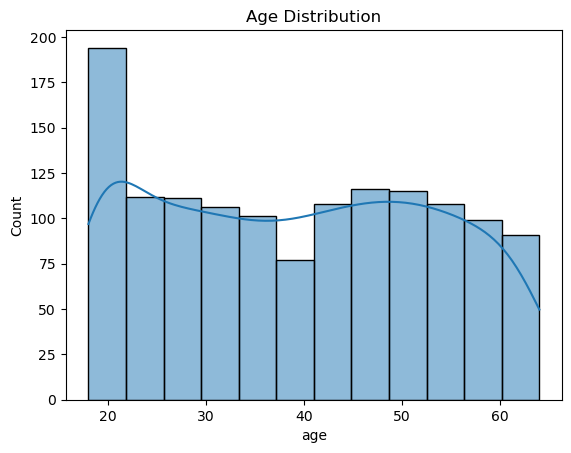

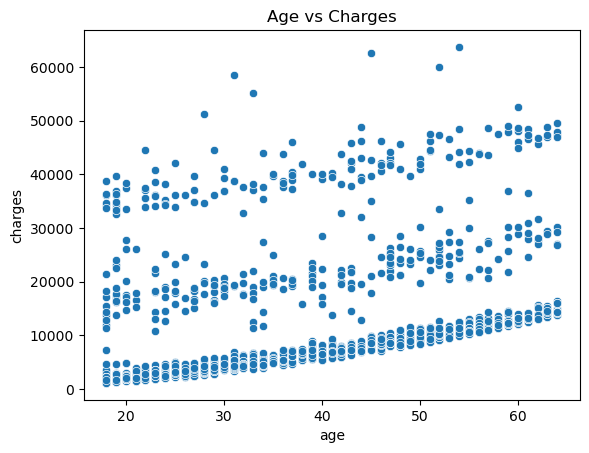

In [27]:
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Charges")
plt.show()

In [28]:
#step 6 data processing 
df['sex'] = df['sex'].map({'male':0, 'female':1})
df['smoker'] = df['smoker'].map({'yes':1, 'no':0})
df['region'] = df['region'].map({
    'southwest':0,
    'southeast':1,
    'northwest':2,
    'northeast':3
})

In [29]:
#step 7 Feature selection 

X = df.drop('charges', axis=1)
y = df['charges']

In [30]:
#step 8 training tesing splitting 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
#step 9 Decision Tree Model
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [32]:
#step 10 Random Forest Model
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [33]:
#step 11 Model Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Decision Tree Results")
print("MAE:", mean_absolute_error(y_test, dt_pred))
print("MSE:", mean_squared_error(y_test, dt_pred))
print("R2 Score:", r2_score(y_test, dt_pred))

print("\nRandom Forest Results")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
print("R2 Score:", r2_score(y_test, rf_pred))

Decision Tree Results
MAE: 2956.878856179105
MSE: 41553067.86566011
R2 Score: 0.7323452020098342

Random Forest Results
MAE: 2531.7586248655166
MSE: 21184644.872166943
R2 Score: 0.863543845617254


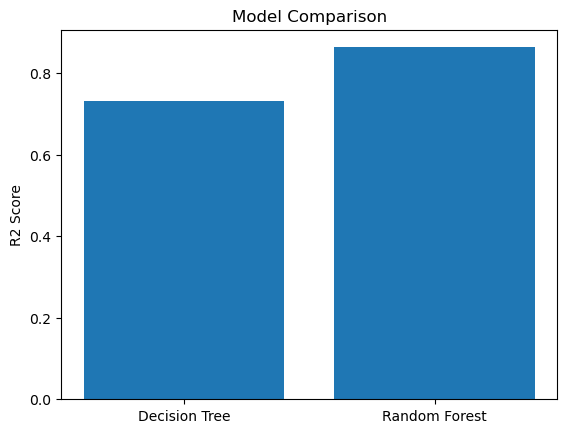

In [34]:
#step 12 Model Comparison 

models = ['Decision Tree', 'Random Forest']
scores = [
    r2_score(y_test, dt_pred),
    r2_score(y_test, rf_pred)
]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("R2 Score")
plt.show()

In [35]:
#step 13 Prediction 
sample = [[25, 1, 28.5, 0, 0, 2]]

print("Decision Tree Prediction:", dt_model.predict(sample)[0])
print("Random Forest Prediction:", rf_model.predict(sample)[0])

Decision Tree Prediction: 3201.24515
Random Forest Prediction: 3111.210358500001


C:\Users\megha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
C:\Users\megha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
